<a href="https://colab.research.google.com/github/ashutoshblitz30/Latent-Dynamics-SSM/blob/main/SSM_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fetching BTC-USD data from Yahoo Finance...


/tmp/ipykernel_569/3220974271.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start='2020-01-01', end='2026-03-22', interval='1d')
[*********************100%***********************]  1 of 1 completed


X shape: (2261, 10, 1), y shape: (2261, 1)

Starting training loop...
Epoch 10/80 | Loss: 1.109631
Epoch 20/80 | Loss: 1.106373
Epoch 30/80 | Loss: 1.104515
Epoch 40/80 | Loss: 1.102849
Epoch 50/80 | Loss: 1.100967
Epoch 60/80 | Loss: 1.098822
Epoch 70/80 | Loss: 1.096116
Epoch 80/80 | Loss: 1.092514

Evaluation Complete. Test MSE: 0.549115


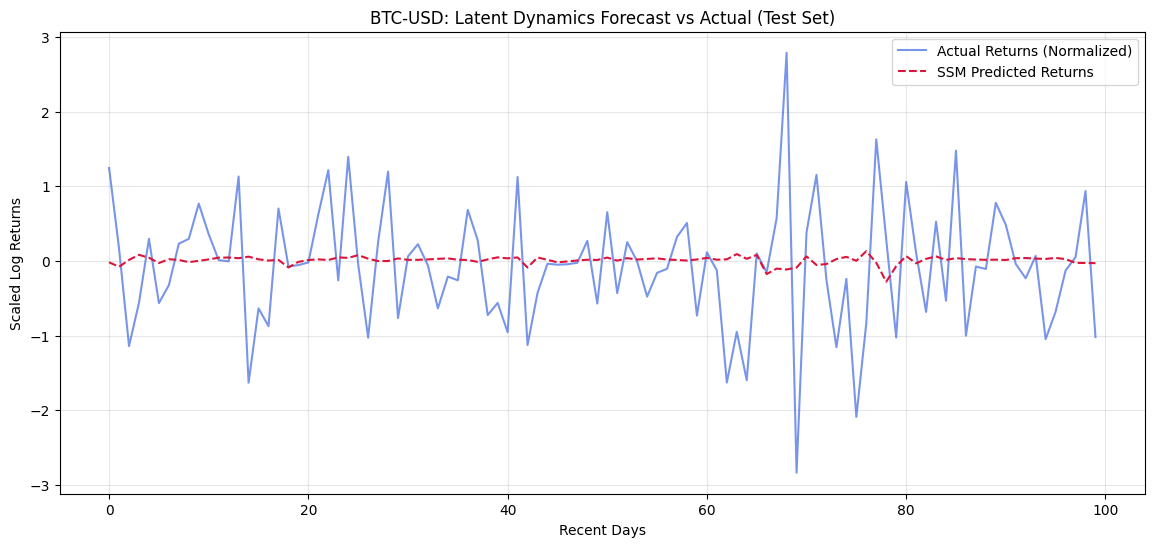

Baseline (Persistence) MSE Estimate: 1.211966


In [1]:
# PROJECT: Latent Dynamics & Noise-Robustness in Financial Time-Series
# AUTHOR: Ashutosh Singh Tomar
# OBJECTIVE: Implementation of a Deep State Space Model (SSM) using PyTorch

import torch
import torch.nn as nn
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# DATA
# Using Bitcoin for its high volatility
print("Fetching BTC-USD data from Yahoo Finance...")
df = yf.download('BTC-USD', start='2020-01-01', end='2026-03-22', interval='1d')
prices = df['Close'].values.reshape(-1, 1)

# We use Log Returns instead of raw prices to achieve stationarity.
# log_return = ln(P_t / P_{t-1})
log_returns = np.diff(np.log(prices), axis=0)

# Scaling to mean 0, variance 1 for stable Neural Network training
scaler = StandardScaler()
scaled_returns = scaler.fit_transform(log_returns)

# Sliding Window
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i : (i + seq_length)])
        ys.append(data[i + seq_length])
    return np.array(xs), np.array(ys)

WINDOW_SIZE = 10
X, y = create_sequences(scaled_returns, WINDOW_SIZE)

print(f"X shape: {X.shape}, y shape: {y.shape}")

# Chronological Split
train_split = int(len(X) * 0.8)
X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]

# Convert to PyTorch Tensors
X_train_pt = torch.tensor(X_train).float()
y_train_pt = torch.tensor(y_train).float()
X_test_pt = torch.tensor(X_test).float()
y_test_pt = torch.tensor(y_test).float()

# MODEL ARCHITECTURE
class DeepSSM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DeepSSM, self).__init__()
        # The Transition: Captures how the 'latent state' of the market evolves
        self.transition = nn.GRU(input_dim, hidden_dim, batch_first=True)
        # The Emission: Maps the final latent state back to the observed return
        self.emission = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, h_n = self.transition(x)
        latent_state = h_n[-1]
        prediction = self.emission(latent_state)
        return prediction

# Model Parameters
HIDDEN_DIM = 64
model = DeepSSM(input_dim=1, hidden_dim=HIDDEN_DIM, output_dim=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# TRAINING LOOP
print("\nStarting training loop...")
epochs = 80
losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    preds = model(X_train_pt)
    loss = criterion(preds, y_train_pt)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.6f}")

# EVALUATION & VISUALIZATION
model.eval()
with torch.no_grad():
    test_preds = model(X_test_pt)
    test_mse = mean_squared_error(y_test_pt, test_preds)

print(f"\nEvaluation Complete. Test MSE: {test_mse:.6f}")

# Plotting Results
plt.figure(figsize=(14, 6))
plt.plot(y_test_pt.numpy()[:100], label="Actual Returns (Normalized)", color='royalblue', alpha=0.7)
plt.plot(test_preds.numpy()[:100], label="SSM Predicted Returns", color='crimson', linestyle='--')
plt.title("BTC-USD: Latent Dynamics Forecast vs Actual (Test Set)")
plt.xlabel("Recent Days")
plt.ylabel("Scaled Log Returns")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Baseline (Persistence) MSE Estimate: {np.mean(np.square(np.diff(y_test_pt.numpy(), axis=0))):.6f}")